# Layer norm experiment
## Fix N, d, alpha_X
## Generate an N * d X with tail exponent alpha_X
## calculate PP(X), actual alpha_X
## for each individual column, demean and normalise, to obtain Xnormalised
## calculate PP(Xnormalised), actual alpha_Xnormalised
### PatnaikPearson_normalisation_20260507.ipynb

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

# Experiment One: Pareto. Fix N, d and let alpha_X vary

In [4]:
this_N = 2000
this_d = 1000

alpha_X_vals = np.arange(0.05,4.0,0.05)
num_values = len(alpha_X_vals)

pp_dim_X_vals = np.zeros(num_values)
nu_over_d_X_vals = np.zeros(num_values)
actual_alpha_X_vals = np.zeros(num_values)
pp_dim_Xnormalised_vals = np.zeros(num_values)
nu_over_d_Xnormalised_vals = np.zeros(num_values)
actual_alpha_Xnormalised_vals = np.zeros(num_values)

uniform_draws = True
use_pareto = True
use_uniform = False
use_cauchy = False
verbose = False

i = 0
for alpha_X in alpha_X_vals:
	results_dict = pp.normalisation_experiment(this_N, this_d, alpha_X, uniform_draws, use_pareto, use_uniform, use_cauchy, verbose)
	pp_dim_X = results_dict["pp_dim_X"]
	nu_over_d_X = results_dict["nu_over_d_X"]
	actual_alpha_X = results_dict["actual_alpha_X"]
	pp_dim_Xnormalised = results_dict["pp_dim_Xnormalised"] 
	nu_over_d_Xnormalised = results_dict["nu_over_d_Xnormalised"]
	actual_alpha_Xnormalised = results_dict["actual_alpha_Xnormalised"]
	pp_dim_X_vals[i] = pp_dim_X
	nu_over_d_X_vals[i] = nu_over_d_X
	actual_alpha_X_vals[i] = actual_alpha_X
	pp_dim_Xnormalised_vals[i] = pp_dim_Xnormalised
	nu_over_d_Xnormalised_vals[i] = nu_over_d_Xnormalised
	actual_alpha_Xnormalised_vals[i] = actual_alpha_Xnormalised
	print(i, alpha_X, actual_alpha_X, actual_alpha_Xnormalised, nu_over_d_X, nu_over_d_Xnormalised)
	i +=1

0 0.05 0.2928936503780545 0.29290315038909615 0.0010000019267001764 0.001000055667651726
1 0.1 0.29324982850624043 0.30726139798314483 0.0010020182860295604 0.0010838244784262784
2 0.15000000000000002 0.29663312305192646 0.32069038115450876 0.0010213244259731477 0.0011670265874542778
3 0.2 0.30560612292765893 0.3590176757438371 0.0010739016537306936 0.0014339162371806201
4 0.25 0.3201274172632828 0.3967080880352313 0.0011634393346719992 0.0017474500385982542
5 0.3 0.3422394823423783 0.4271217802251736 0.001311337910032792 0.0020466323879791727
6 0.35000000000000003 0.3651843985423763 0.46421371381718324 0.0014814277849956332 0.002481795944579112
7 0.4 0.3967443455517527 0.507190939053754 0.0017477801494358465 0.00311000505689745
8 0.45 0.4296059924900235 0.5412842786994528 0.002073187775379036 0.003730902152112513
9 0.5 0.4654504033522786 0.5801676172238394 0.002497852314951443 0.004610615261502962
10 0.55 0.5018195566793062 0.6131892148022634 0.0030229060147550298 0.005538806042395151

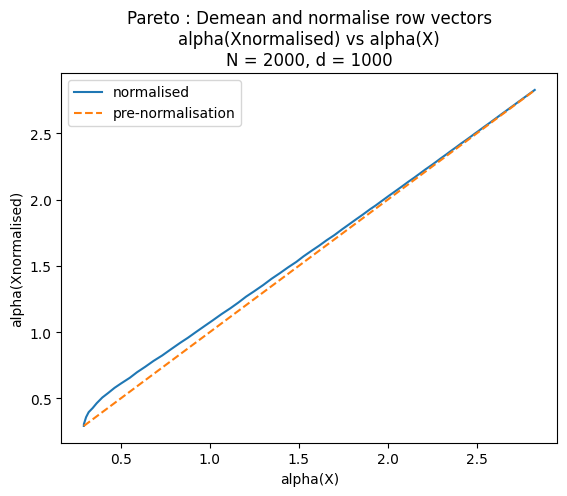

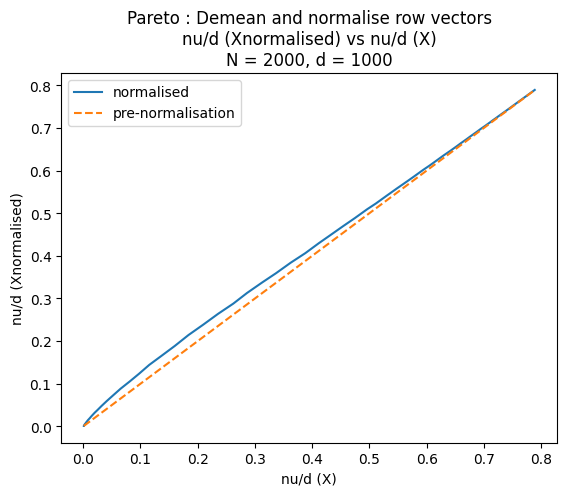

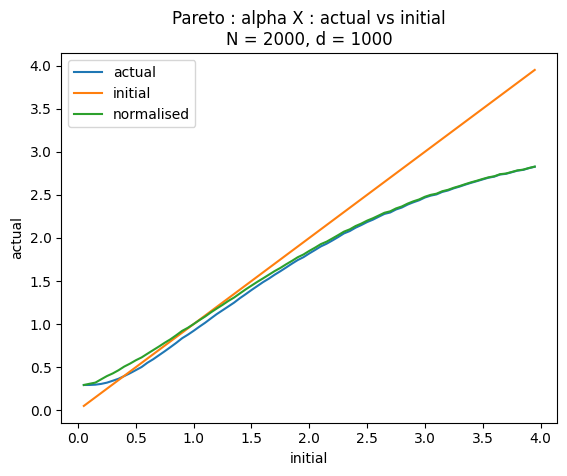

In [8]:
this_title = "Pareto : Demean and normalise row vectors\n"
this_title += "alpha(Xnormalised) vs alpha(X)\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(actual_alpha_X_vals, actual_alpha_Xnormalised_vals, label = "normalised")
plt.plot(actual_alpha_X_vals, actual_alpha_X_vals, linestyle = "--", label="pre-normalisation")
plt.xlabel("alpha(X)")
plt.ylabel("alpha(Xnormalised)")
plt.legend()
plt.title(this_title)
#plt.savefig('normalisation_pareto_alpha_Xnormalised_as_alpha_X_varies.pdf', dpi=300, bbox_inches='tight')
plt.show()

this_title = "Pareto : Demean and normalise row vectors\n"
this_title += "nu/d (Xnormalised) vs nu/d (X)\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(nu_over_d_X_vals, nu_over_d_Xnormalised_vals, label = "normalised")
plt.plot(nu_over_d_X_vals, nu_over_d_X_vals, linestyle = "--", label="pre-normalisation")
plt.xlabel("nu/d (X)")
plt.ylabel("nu/d (Xnormalised)")
plt.legend()
plt.title(this_title)
#plt.savefig('normalisation_pareto_nu_over_d_Xnormalised_as_nu_over_d_X_varies.pdf', dpi=300, bbox_inches='tight')
plt.show()

this_title = "Pareto : alpha X : actual vs initial\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(alpha_X_vals, actual_alpha_X_vals, label = "actual")
plt.plot(alpha_X_vals, alpha_X_vals, label = "initial")
plt.plot(alpha_X_vals, actual_alpha_Xnormalised_vals, label = "normalised")
plt.xlabel("initial")
plt.ylabel("actual")
plt.legend()
plt.title(this_title)
plt.show()

79


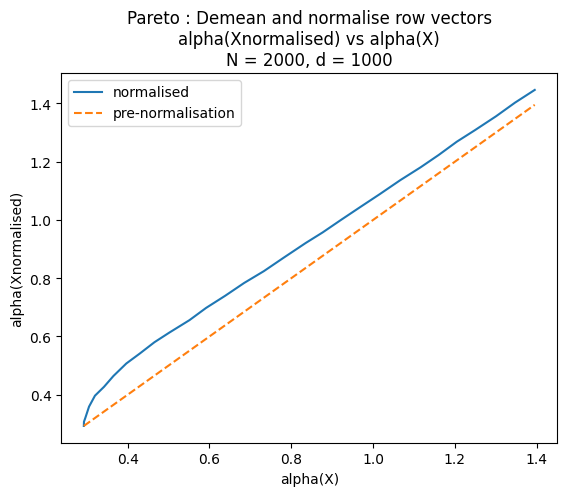

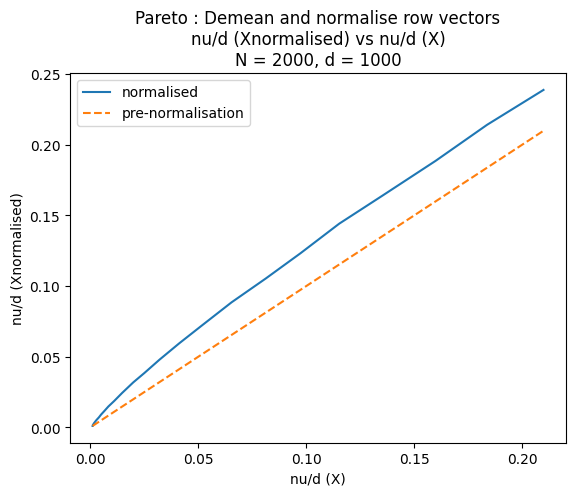

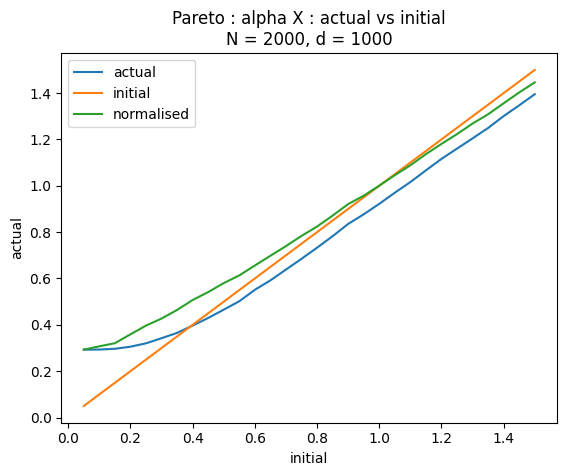

In [12]:
print(len(actual_alpha_X_vals))
k = 30

this_title = "Pareto : Demean and normalise row vectors\n"
this_title += "alpha(Xnormalised) vs alpha(X)\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(actual_alpha_X_vals[0:k], actual_alpha_Xnormalised_vals[0:k], label = "normalised")
plt.plot(actual_alpha_X_vals[0:k], actual_alpha_X_vals[0:k], linestyle = "--", label="pre-normalisation")
plt.xlabel("alpha(X)")
plt.ylabel("alpha(Xnormalised)")
plt.legend()
plt.title(this_title)
plt.savefig('normalisation_pareto_alpha_Xnormalised_as_alpha_X_varies_two.pdf', dpi=300, bbox_inches='tight')
plt.show()

this_title = "Pareto : Demean and normalise row vectors\n"
this_title += "nu/d (Xnormalised) vs nu/d (X)\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(nu_over_d_X_vals[0:k], nu_over_d_Xnormalised_vals[0:k], label = "normalised")
plt.plot(nu_over_d_X_vals[0:k], nu_over_d_X_vals[0:k], linestyle = "--", label="pre-normalisation")
plt.xlabel("nu/d (X)")
plt.ylabel("nu/d (Xnormalised)")
plt.legend()
plt.title(this_title)
plt.savefig('normalisation_pareto_nu_over_d_Xnormalised_as_nu_over_d_X_varies_two.pdf', dpi=300, bbox_inches='tight')
plt.show()

this_title = "Pareto : alpha X : actual vs initial\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(alpha_X_vals[0:k], actual_alpha_X_vals[0:k], label = "actual")
plt.plot(alpha_X_vals[0:k], alpha_X_vals[0:k], label = "initial")
plt.plot(alpha_X_vals[0:k], actual_alpha_Xnormalised_vals[0:k], label = "normalised")
plt.xlabel("initial")
plt.ylabel("actual")
plt.legend()
plt.title(this_title)
plt.show()

In [9]:
print(len(actual_alpha_X_vals))

79
